# Basis for SVM model (needs to be adjusted to data and de-bugged)
Model basis below is based on work done for Programming Assignment #3. When the data set is done, we can try to run it and finish it. 

In [1]:
# importing libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import nltk
from nltk.stem import WordNetLemmatizer
import sklearn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import datasets, linear_model, metrics
from sklearn import datasets, svm
from sklearn.metrics import ConfusionMatrixDisplay

In [54]:
def classification_report(predictions, labels, name):
    accuracy = metrics.accuracy_score(labels, predictions) * 100
    precis= metrics.precision_score(labels,predictions, average='micro') * 100
    recall=metrics.recall_score(labels,predictions, average='micro') * 100
    f1=metrics.f1_score(labels,predictions, average='micro') * 100

    print("Method Name: "+name)
    print("Accuracy: "+ str(accuracy))
    print("Precision: "+ str(precis))
    print("Recall: "+ str(recall))
    print("F1 Measure: "+ str(f1))


In [2]:
# reading the file
train = pd.read_csv("data/combined/lyrics_train.csv")
eval_  = pd.read_csv("data/combined/lyrics_eval.csv")

X_train, y_train = train["text"], train["L1"]
X_eval,  y_eval  = eval_["text"], eval_["L1"]

print(f"Train: {len(X_train)} songs, classes: {y_train.value_counts().to_dict()}")
print(f"Eval:  {len(X_eval)} songs, classes: {y_eval.value_counts().to_dict()}")

Train: 69 songs, classes: {'spanish': 41, 'italian': 18, 'french': 10}
Eval:  30 songs, classes: {'spanish': 22, 'italian': 6, 'french': 2}


In [5]:
# adding a heading
train.head()

,artist_slug,artist_name,song_id,title,url,text,word_count,english_ratio,n_english_lines,n_total_lines,featured_artists,L1,genius_artist_id,lyrics,english_word_count
0,freeze_corleone,Freeze Corleone,6724242,Polémique,https://genius.com/Freeze-corleone-polemique-l...,"Yo Freeze, we're doing one ten through the cou...",NaN,0.344262,21,61,Central Cee,french,63888.0,S/o le Flem\nAllô ? Cee ? C'est comment ? T'as...,243.0
1,lomepal,Lomepal,4144358,Ma cousin,https://genius.com/Lomepal-ma-cousin-lyrics,"Um, like, don't come 'round here and try to fu...",NaN,0.191176,13,68,NaN,french,16138.0,Ahlan wa sahlan bikom 3ala track Lomepal 14 fi...,155.0
2,youssoupha,Youssoupha,62326,Dreamin’,https://genius.com/Youssoupha-dreamin-lyrics,"Miss me, miss me, you're the one who makes me ...",NaN,0.484848,32,66,Indila,french,1684.0,"Miss me, miss me, you're the one who makes me ...",243.0
3,youssoupha,Youssoupha,708823,Smile,https://genius.com/Youssoupha-smile-lyrics,"You make me, you make me, you make me smile\nY...",NaN,0.245283,13,53,Madame Monsieur,french,1684.0,Laisse tourner l'son\nOù sont les sourires au ...,142.0
4,sinik,Sinik,81907,Rue du paradis,https://genius.com/Sinik-rue-du-paradis-lyrics,Every day I wake up I feel like crying\nEvery ...,NaN,0.523810,44,84,NaN,french,1877.0,Every day I wake up I feel like crying\nEvery ...,319.0


In [87]:
# splitting the data
X = X_train
y = y_train
vectorizer = CountVectorizer() 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=13) # re-splitting the data

print(f"Train: {len(X_train)} songs, classes: {y_train.value_counts().to_dict()}")
print(f"Eval:  {len(X_test)} songs, classes: {y_test.value_counts().to_dict()}")

X_train_vec = vectorizer.fit_transform(X_train) # vectorize training data and fit vectorizer
X_test_vec = vectorizer.transform(X_test) # vectorize test data 


Train: 23 songs, classes: {'spanish': 12, 'italian': 6, 'french': 5}
Eval:  5 songs, classes: {'spanish': 3, 'french': 1, 'italian': 1}


In [127]:
# making a linear SVM model
svm_model = svm.LinearSVC(C=0.1, max_iter=1000, class_weight='balanced')
trained_svm = svm_model.fit(X_train_vec, y_train) 

y_pred_svm = trained_svm.predict(X_test_vec)


In [121]:
classification_report(y_pred_svm, y_test, "LinearSVM")

Method Name: LinearSVM
Accuracy: 60.0
Precision: 60.0
Recall: 60.0
F1 Measure: 60.0


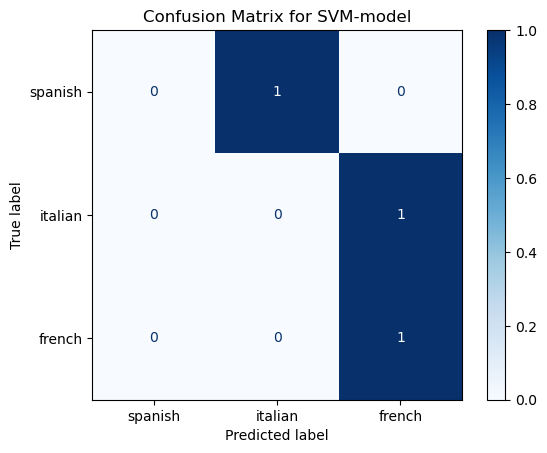

Confusion Matrix for SVM-model
[[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [123]:
# making a confusion matrix

np.set_printoptions(precision=2)

title = "Confusion Matrix for SVM-model"
class_names = ["spanish", 'italian', 'french'] 

disp = ConfusionMatrixDisplay.from_estimator(
    trained_svm,
    X_test_vec,
    y_test,
    display_labels=class_names,
    cmap=plt.cm.Blues,
    normalize='true'
)

disp.ax_.set_title(title)

plt.show()


print(title)
print(disp.confusion_matrix)

In [129]:
# making a SVM model
svm_model_nl = svm.SVC(C=0.1, max_iter=1000, class_weight='balanced')
trained_svm_nl = svm_model_nl.fit(X_train_vec, y_train) 

y_pred_svm_nl = trained_svm.predict(X_test_vec)


In [133]:
classification_report(y_pred_svm_nl, y_test, "SVM")

Method Name: SVM
Accuracy: 60.0
Precision: 60.0
Recall: 60.0
F1 Measure: 60.0


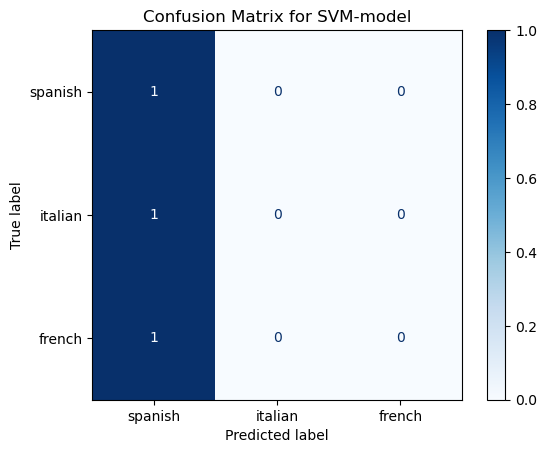

Confusion Matrix for SVM-model
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [135]:
# making a confusion matrix

np.set_printoptions(precision=2)

title = "Confusion Matrix for SVM-model"
class_names = ["spanish", 'italian', 'french'] 

disp = ConfusionMatrixDisplay.from_estimator(
    trained_svm_nl,
    X_test_vec,
    y_test,
    display_labels=class_names,
    cmap=plt.cm.Blues,
    normalize='true'
)

disp.ax_.set_title(title)

plt.show()


print(title)
print(disp.confusion_matrix)